# Intelligent Automation 2026/27- Assignment 1

To be delivered until 2026-10-09 23:59:59.

**Submission Notes**:
- Create a folder in your group's GitHub repository to solve this assignment. Copy this notebook into that folder.
- You should commit regularly to your repository the answers to the questions in this notebook. If you do not, your grade will be penalized by 1/20 points.
- After running the entire notebook (including graphs and outputs), save the notebook as a .pdf file, by going to File - Print - Destination: Save as PDF.
- Create a .zip file containing both the .ipynb file (the notebook itself) and the .pdf and submit it in Fénix.

# Problem description

The dataset for this assignment contains information on students from two Portuguese secondary schools enrolled in a mathematics course.
Each row corresponds to one student and includes demographic and family background variables (e.g., basic personal and household characteristics), school-related variables (e.g., school context, study habits, past failures), behavioral and lifestyle indicators (e.g., free time, going out, alcohol use), and the grades for the three school periods, on a 0–20 scale.

The goal is to predict the performance of the students in the final period.
First, the problem will be approached as a classification task, predicting whether a student will pass (G3 >= 10) or fail (G3 < 10) the course.
Then, the problem will be approached as a regression task, predicting the actual final grade (G3).

A detailed description of all variables (family context, behavioral, school performance, etc.) is provided in the file `feature_description.txt`.

In [41]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.metrics import (
    confusion_matrix, ConfusionMatrixDisplay, classification_report,
    accuracy_score, precision_score, recall_score, f1_score,
    average_precision_score, roc_auc_score,
    mean_squared_error, r2_score
)

# Part 1 - Data exploration **(4.00)**

##### **1.1.** Load the dataset from the CSV file `mathematics_grades.csv`. **(0.25)**

In [42]:
dados = pd.read_csv("mathematics_grades.csv")

print(dados.shape)
dados.head()

(357, 34)


,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3,failed
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,3,4,1,1,3,6,5,6,6,True
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,3,3,1,1,3,4,5,5,6,True
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,3,2,2,3,3,10,7,8,10,False
3,GP,F,15,U,GT3,T,4,2,health,services,...,2,2,1,1,5,2,15,14,15,False
4,GP,F,16,U,GT3,T,3,3,other,other,...,3,2,1,2,5,4,6,10,10,False


##### **1.2.** Identify the feature types of each variable in the dataset. **(1.50)**

In [43]:
print(dados.dtypes)

binary_features = ["school", "sex", "address", "famsize", "Pstatus",
                   "schoolsup", "famsup", "paid", "activities",
                   "nursery", "higher", "internet", "romantic"]

nominal_features = ["Mjob", "Fjob", "reason", "guardian"]

ordinal_features = ["Medu", "Fedu", "traveltime", "studytime", "famrel",
                    "freetime", "goout", "Dalc", "Walc", "health"]

numerical_features = ["age", "failures", "absences", "G1", "G2", "G3"]

target_derived = ["failed"]

school        object
sex           object
age            int64
address       object
famsize       object
Pstatus       object
Medu           int64
Fedu           int64
Mjob          object
Fjob          object
reason        object
guardian      object
traveltime     int64
studytime      int64
failures       int64
schoolsup     object
famsup        object
paid          object
activities    object
nursery       object
higher        object
internet      object
romantic      object
famrel         int64
freetime       int64
goout          int64
Dalc           int64
Walc           int64
health         int64
absences       int64
G1             int64
G2             int64
G3             int64
failed          bool
dtype: object


##### **1.3** Check if the dataset has missing values. If so, discard any row that has a missing value. **(0.25)**

In [44]:
print(dados.isna().sum().sum(), "missing values in total")
print(dados.isna().sum()[dados.isna().sum() > 0])

rows_before = len(dados)
dados = dados.dropna()
print(f"Rows before: {rows_before} | Rows after: {len(dados)}")

0 missing values in total
Series([], dtype: int64)
Rows before: 357 | Rows after: 357


##### **1.4.** Make a pairplot of the numerical variables, colored by the `failed` variable. **(0.50)**

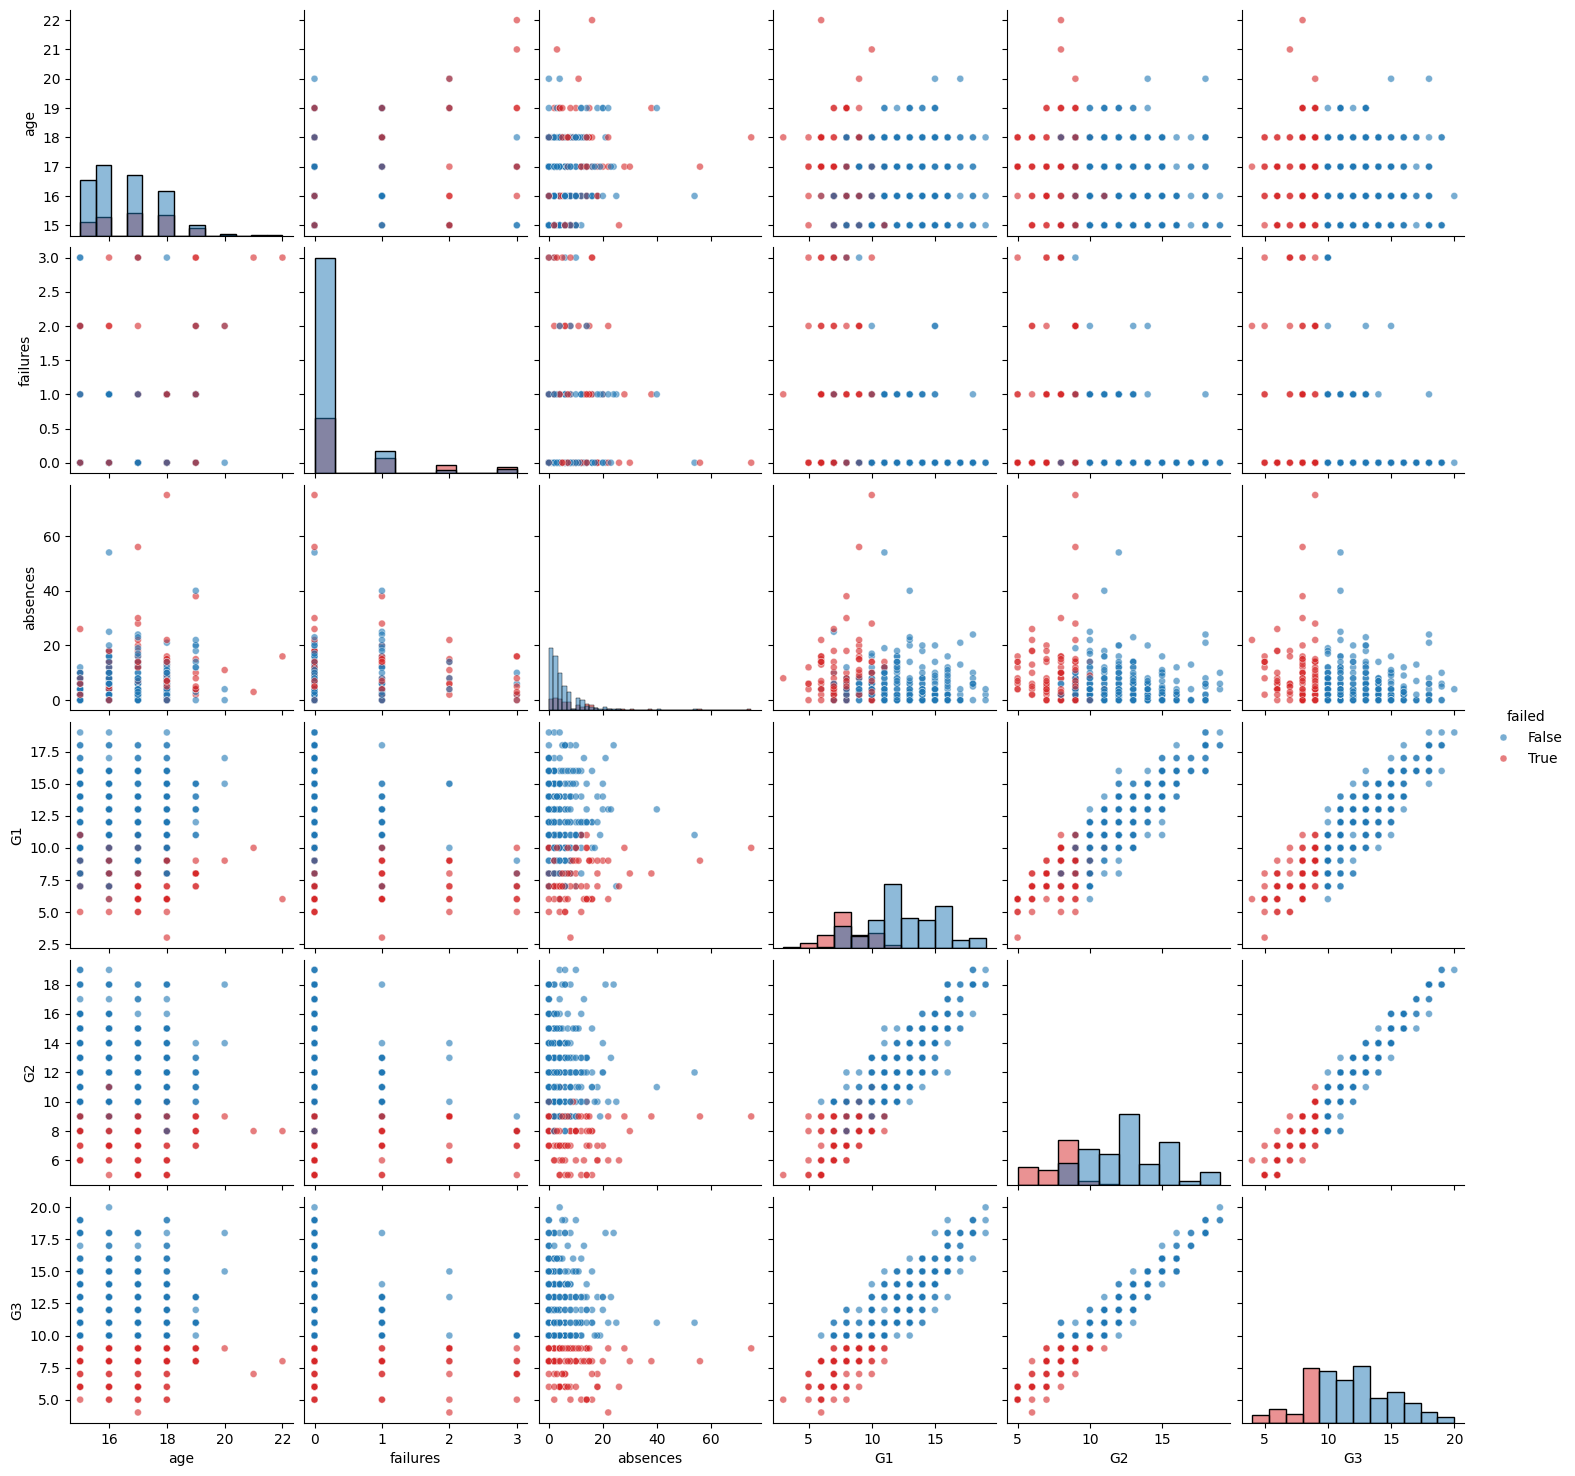

In [45]:
sns.pairplot(dados, vars=numerical_features, hue="failed",
             palette={False: "tab:blue", True: "tab:red"},
             diag_kind="hist", plot_kws={"alpha": 0.6, "s": 25})
plt.show()

##### **1.5.** Make bar plots for each categorical variable, showing the counts for each category, colored by the `failed` variable. **(0.50)**

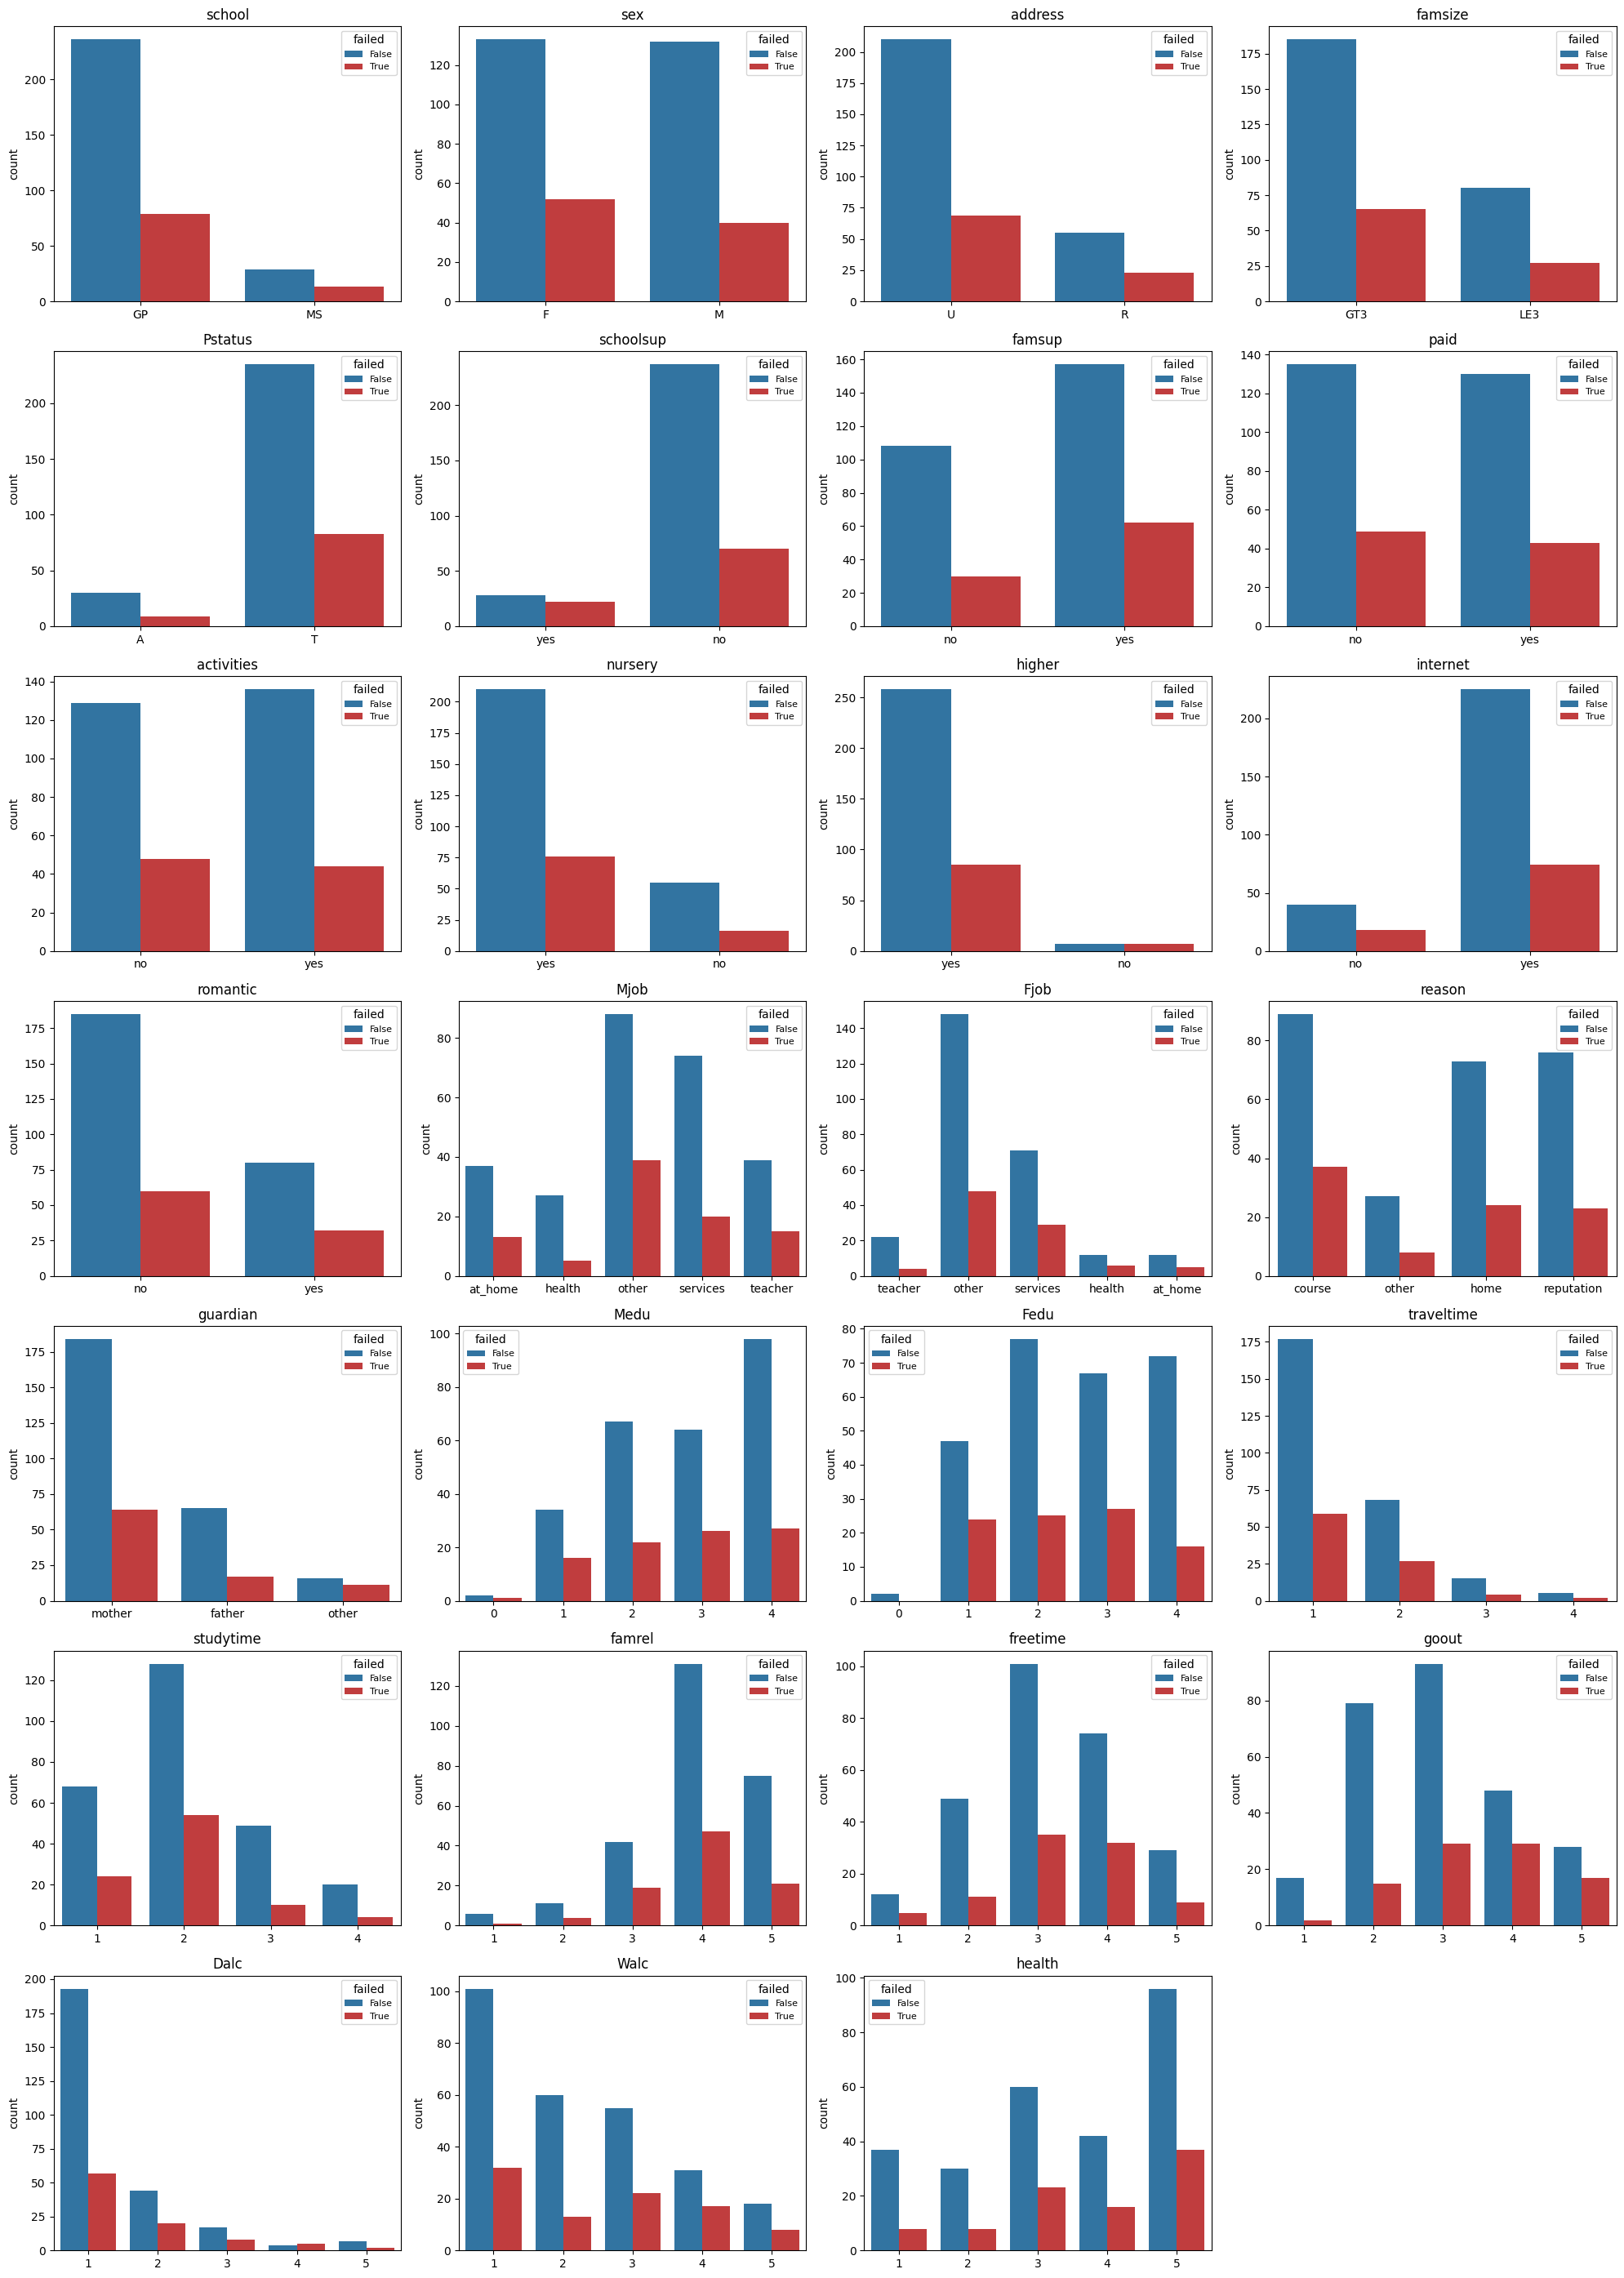

In [46]:
categorical_features = binary_features + nominal_features + ordinal_features

n_cols = 4
n_rows = int(np.ceil(len(categorical_features) / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 4 * n_rows))
axes = axes.flatten()

for ax, col in zip(axes, categorical_features):
    sns.countplot(data=dados, x=col, hue="failed",
                  palette={False: "tab:blue", True: "tab:red"}, ax=ax)
    ax.set_title(col)
    ax.set_xlabel("")
    ax.legend(title="failed", fontsize=8)

# hide any unused panels
for ax in axes[len(categorical_features):]:
    ax.set_visible(False)

plt.tight_layout()
plt.show()

##### **1.6.** In each school, how many students live in a rural area and do not have internet access at home? **(0.50)**

In [47]:
result = (
    dados[
        (dados['address'] == 'R') &
        (dados['internet'] == 'no')
    ]
    .groupby('school')
    .size()
    .reindex(dados['school'].unique(), fill_value=0)
)

print(result)

school
GP    17
MS     7
dtype: int64


##### **1.7.** Split the dataset into a training set (80%) and a test set (20%). **(0.50)**

In [48]:
# Features and target
X = dados.drop('failed', axis=1)
y = dados['failed']

# Split: 80% training, 20% test
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=2026
)

print("Training set:", X_train.shape)
print("Test set:", X_test.shape)

Training set: (285, 33)
Test set: (72, 33)


# Part 2 - Classification **(7.50)**

##### You'll start by approaching the problem as a classification task, predicting whether a student will pass (G3 >= 10) or fail (G3 < 10) the course. Consider the variable `failed` as the target variable.

##### **2.1.** Which performance metric do you think are most important for this prediction task, and why? Justify your answer in the context of supporting students who may struggle academically. **(2.00)**

Given that the objective of the model is to be able to detect struggling students, the most important metrics would be recall for the Failed Class category and the F2-score because, analysing the problem, we can conclude that a false negative would be a costly error, as we would be missing the main target of the model, and a false positive wouldn't be as costly an error, but would still not be ideal.

Maximizing recall would trivially mean attributing the Failed Class category to every student, so the F2-score balances recall.

##### **2.2.** Build a logistic regression model to predict whether a student will pass or fail the course, using as predictor the feature `absences`. Evaluate the performance of the model on the test set using a confusion matrix, accuracy, precision, recall, f1-score and the metric you selected in question 2.1. **(0.50)**

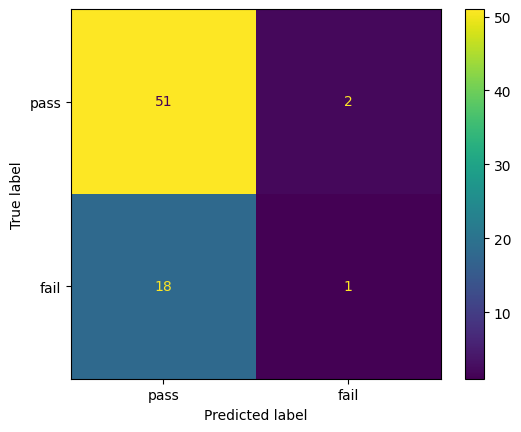

Accuracy : 0.722
Precision: 0.333
Recall   : 0.053
F1-score : 0.091
PR-AUC   : 0.460
ROC-AUC  : 0.708


In [49]:

X = dados[["absences"]]
y = dados["failed"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42)

log_reg = LogisticRegression()
log_reg.fit(X_train, y_train)

y_pred = log_reg.predict(X_test)
y_prob = log_reg.predict_proba(X_test)[:, 1]   # probability of failing

# confusion matrix
cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm, display_labels=["pass", "fail"]).plot()
plt.show()

# metrics (positive class = failed = True)
print(f"Accuracy : {accuracy_score(y_test, y_pred):.3f}")
print(f"Precision: {precision_score(y_test, y_pred, zero_division=0):.3f}")
print(f"Recall   : {recall_score(y_test, y_pred):.3f}")
print(f"F1-score : {f1_score(y_test, y_pred):.3f}")
print(f"PR-AUC   : {average_precision_score(y_test, y_prob):.3f}")
print(f"ROC-AUC  : {roc_auc_score(y_test, y_prob):.3f}")

##### **2.3.** The model you built in question 2.2 likely does not perform very well. Explain why this is the case, considering the distribution of the predictor and the response. How can you improve the model? **(2.00)**

There is a large imbalance in both classes we want to predict. Most of the students pass, so the model, without weighting the classes, minimizes the log loss, which is dominated by the majority class. The model therefore predicts Pass for almost every student, which gives good accuracy but basically 0 recall. The predictor is also unbalanced, where we see most students with some absences and some rare cases with many more than the norm.

To improve the model, we can take into account balanced class weights, add more predictors, or change the threshold for the classification.

##### **2.4.** Consider now the variable `studytime` as the predictor and assume it is numerical. Build a logistic regression model to predict whether a student will pass or fail the course. Evaluate the performance of the model on the test set using a confusion matrix, accuracy, precision, recall, f1-score and the metric you selected in question 2.1. **(0.50)**

Note: Use `sklearn.linear_model.LogisticRegression(class_weight='balanced')` for your logistic regression model.

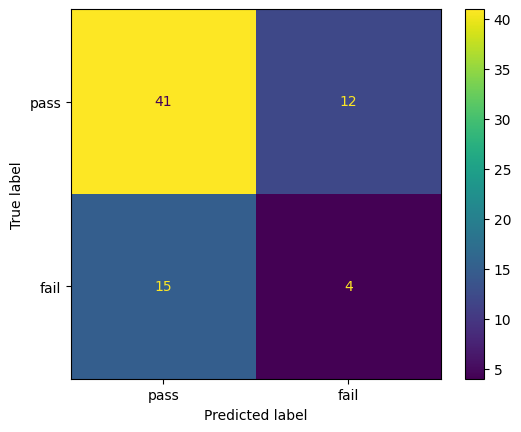

Accuracy : 0.625
Precision: 0.250
Recall   : 0.211
F1-score : 0.229
PR-AUC   : 0.328
ROC-AUC  : 0.623


In [50]:
X = dados[["studytime"]]          # treated as numerical (no encoding)
y = dados["failed"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42)

log_reg_study = LogisticRegression(class_weight="balanced")
log_reg_study.fit(X_train, y_train)

y_pred = log_reg_study.predict(X_test)
y_prob = log_reg_study.predict_proba(X_test)[:, 1]

cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm, display_labels=["pass", "fail"]).plot()
plt.show()

print(f"Accuracy : {accuracy_score(y_test, y_pred):.3f}")
print(f"Precision: {precision_score(y_test, y_pred, zero_division=0):.3f}")
print(f"Recall   : {recall_score(y_test, y_pred):.3f}")
print(f"F1-score : {f1_score(y_test, y_pred):.3f}")
print(f"PR-AUC   : {average_precision_score(y_test, y_prob):.3f}")
print(f"ROC-AUC  : {roc_auc_score(y_test, y_prob):.3f}")

##### **2.5.** Repeat question 2.4, but now considering `studytime` as a categorical variable. **(0.50)**

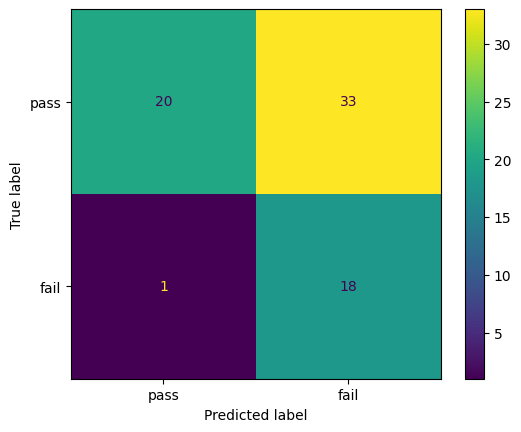

Accuracy : 0.528
Precision: 0.353
Recall   : 0.947
F1-score : 0.514
PR-AUC   : 0.383
ROC-AUC  : 0.702


In [51]:
X = pd.get_dummies(dados["studytime"].astype("category"),
                   prefix="studytime", drop_first=True, dtype=int)
y = dados["failed"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42)

log_reg_cat = LogisticRegression(class_weight="balanced")
log_reg_cat.fit(X_train, y_train)

y_pred = log_reg_cat.predict(X_test)
y_prob = log_reg_cat.predict_proba(X_test)[:, 1]

cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm, display_labels=["pass", "fail"]).plot()
plt.show()

print(f"Accuracy : {accuracy_score(y_test, y_pred):.3f}")
print(f"Precision: {precision_score(y_test, y_pred, zero_division=0):.3f}")
print(f"Recall   : {recall_score(y_test, y_pred):.3f}")
print(f"F1-score : {f1_score(y_test, y_pred):.3f}")
print(f"PR-AUC   : {average_precision_score(y_test, y_prob):.3f}")
print(f"ROC-AUC  : {roc_auc_score(y_test, y_prob):.3f}")

##### **2.6.** What is the difference between the two models you built in questions 2.4 and 2.5? Plot the predictions of each model over the range of `studytime` values in the test set. What are the advantages and disadvantages of each approach? **(2.00)**


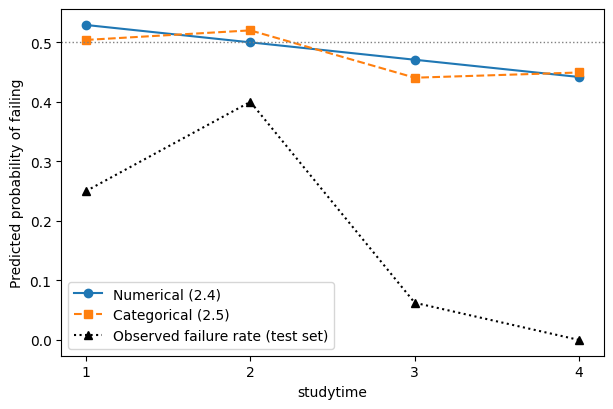

In [52]:
# studytime values of the students in the test set
test_studytime = df.loc[X_test.index, "studytime"]
levels = np.sort(test_studytime.unique())    # [1, 2, 3, 4]

# numerical model (2.4)
p_num = log_reg_study.predict_proba(pd.DataFrame({"studytime": levels}))[:, 1]

# categorical model (2.5): same dummy columns as in training
dummies = pd.get_dummies(pd.Categorical(levels, categories=[1, 2, 3, 4]),
                         prefix="studytime", drop_first=True, dtype=int)
p_cat = log_reg_cat.predict_proba(dummies)[:, 1]

# observed failure rate per level in the test set
obs = df.loc[X_test.index].groupby("studytime")["failed"].mean()

plt.figure(figsize=(7, 4.5))
plt.plot(levels, p_num, "o-", label="Numerical (2.4)")
plt.plot(levels, p_cat, "s--", label="Categorical (2.5)")
plt.plot(obs.index, obs.values, "k^:", label="Observed failure rate (test set)")
plt.axhline(0.5, color="gray", lw=1, ls=":")
plt.xticks(levels)
plt.xlabel("studytime")
plt.ylabel("Predicted probability of failing")
plt.legend()
plt.show()

The numerical aproach

# Part 3 - Regression (3.50)

##### In this part of the assignment, you'll approach the problem as a regression task, predicting the actual final grade `G3`. Use the same training and test sets you created in Part 1.

In [53]:
# Features and target
X = dados.drop('failed', axis=1)
y = dados['failed']

# Split: 80% training, 20% test
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=2026
)

print("Training set:", X_train.shape)
print("Test set:", X_test.shape)

Training set: (285, 33)
Test set: (72, 33)


##### **3.1.** Build a linear regression model to predict the final grade `G3`, using as predictor the feature `G2`. Evaluate the performance of the model on the test set using Mean Squared Error (MSE) and R-squared ($R^2$). **(0.50)**

In [54]:

# same split as before: X_train / X_test keep the row index of df
y_train_reg = dados.loc[X_train.index, "G3"]
y_test_reg  = dados.loc[X_test.index, "G3"]

X_train_g2 = dados.loc[X_train.index, ["G2"]]
X_test_g2  = dados.loc[X_test.index, ["G2"]]

lin_reg = LinearRegression()
lin_reg.fit(X_train_g2, y_train_reg)

y_pred_reg = lin_reg.predict(X_test_g2)

print(f"Intercept: {lin_reg.intercept_:.3f}")
print(f"Slope (G2): {lin_reg.coef_[0]:.3f}")
print(f"MSE: {mean_squared_error(y_test_reg, y_pred_reg):.3f}")
print(f"R²: {r2_score(y_test_reg, y_pred_reg):.3f}")

Intercept: 0.146
Slope (G2): 1.001
MSE: 0.789
R²: 0.929


##### **3.2.** Print the equation of the model you built in question 3.1. Plot the predictions of the model as a function of the inputs, along with the actual data points from the test set. Interpret the coefficients of the model. **(1.00)**


G3 = 0.146 + 1.001 * G2


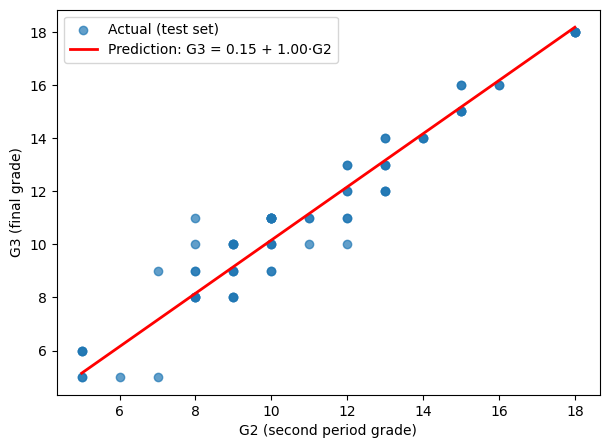

In [55]:
b0 = lin_reg.intercept_
b1 = lin_reg.coef_[0]

print(f"G3 = {b0:.3f} + {b1:.3f} * G2")

# plot: test points and regression line
x_line = np.linspace(X_test_g2["G2"].min(), X_test_g2["G2"].max(), 100)
y_line = lin_reg.predict(pd.DataFrame({"G2": x_line}))

plt.figure(figsize=(7, 5))
plt.scatter(X_test_g2["G2"], y_test_reg, alpha=0.7, label="Actual (test set)")
plt.plot(x_line, y_line, color="red", lw=2,
         label=f"Prediction: G3 = {b0:.2f} + {b1:.2f}·G2")
plt.xlabel("G2 (second period grade)")
plt.ylabel("G3 (final grade)")
plt.legend()
plt.show()

A slope close to 1 means that the students tend to keep their level from G2 to G3. Given that there are few points with 0 in G2, and some of them have G3 equal to 0, we shouldn't interpret the 0.15 as a meaningful relation between G2 and G3, just a practical coefficient to align the plot.

##### **3.3.** Build a linear regression model to predict the final grade `G3`, using as predictors all features except the variables related to the grades (`G1`, `G2`, `G3`, `failed`). Explain the choices you made. Evaluate the performance of the model on the test set using Mean Squared Error (MSE) and R-squared ($R^2$). Plot the predicted vs actual values of `G3` for the test set. **(1.00)**

Test  MSE: 9.942
Test  R²:  0.105
Train MSE: 6.461
Train R²:  0.365


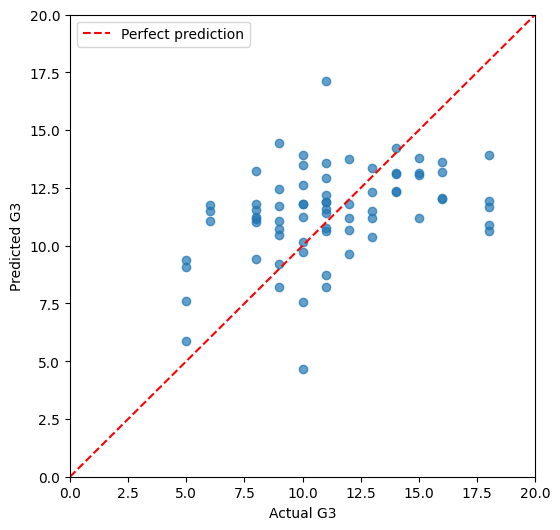

In [56]:


# predictors: everything except G1, G2, G3 and failed
features = binary_features + nominal_features + ordinal_features + ["age", "failures", "absences"]

train_df = dados.loc[X_train.index]
test_df  = dados.loc[X_test.index]

preprocess = ColumnTransformer([
    ("cat", OneHotEncoder(drop="first"), binary_features + nominal_features),
    ("num", StandardScaler(), ordinal_features + ["age", "failures", "absences"])
])

model_all = Pipeline([
    ("prep", preprocess),
    ("lr", LinearRegression())
])

model_all.fit(train_df[features], train_df["G3"])

y_pred_all = model_all.predict(test_df[features])
y_pred_tr  = model_all.predict(train_df[features])

print(f"Test  MSE: {mean_squared_error(test_df['G3'], y_pred_all):.3f}")
print(f"Test  R²:  {r2_score(test_df['G3'], y_pred_all):.3f}")
print(f"Train MSE: {mean_squared_error(train_df['G3'], y_pred_tr):.3f}")
print(f"Train R²:  {r2_score(train_df['G3'], y_pred_tr):.3f}")

# predicted vs actual
plt.figure(figsize=(6, 6))
plt.scatter(test_df["G3"], y_pred_all, alpha=0.7)
lims = [0, 20]
plt.plot(lims, lims, "r--", label="Perfect prediction")
plt.xlim(lims); plt.ylim(lims)
plt.xlabel("Actual G3")
plt.ylabel("Predicted G3")
plt.legend()
plt.show()

##### **3.4.** In terms of application, what is the difference between building a model to predict student performance using the grades of the previous periods (as in question 3.1) versus using other features (as in question 3.3)? When would each approach be more appropriate? **(1.00)**

In 3.1, we see very good performance, meaning that the grades are autocorrelated and G2 is a good predictor for G3. The downside of this approach is that if the objective is to predict struggling students, G2 is a predictor that we can only obtain during the year; therefore, it is a late predictor for the objective of the model. In 3.3, there is a study of the habits of the students, which are less accurate compared to the grades we can access during the year. Therefore, the approach we choose depends on the timeline we want to adopt for the prediction. If we want to make a prediction before the year begins, we take the 3.3 approach; if we want to conduct a study during the year, we can use more accurate predictors, like in 3.1.

# Part 4 - Cross-validation (4.00)

##### **4.1.** Explain the concept of cross-validation and its importance in evaluating machine learning models. **(1.00)**

Cross-validation is a resampling technique in which the available data are repeatedly divided into training and validation subsets to estimate how well a model generalizes to unseen data.
Cross-validation is important for evaluating machine learning models for several reasons. First, it prevents optimistic bias, evaluating a model directly on the training observations (training error) consistently underestimates the true test error and fails to detect overfitting. Second, it is an alternative to a large held-out test set, when the available dataset is relatively small, holding out a large test set substantially reduces the data available for model fitting, whereas cross-validation provides a reliable estimate of the test error while leveraging all available data across iterations. Third, it supports model assessment and parameter tuning, since it provides a criterion to select the optimal model flexibility, tune parameters, and select the model with the best estimated test error.

##### **4.2.** Describe how K-fold cross-validation works. What values of K should be used? Justify. **(1.00)**

K-fold cross-validation works by randomly splitting the dataset of n observations into K mutually exclusive folds of approximately equal size. The model is evaluated over K iterations, where in each iteration a single fold is held out for validation while the remaining K-1 folds are used for training. The chosen error metric (such as MSE or misclassification rate) is computed on the held-out fold, and the overall cross-validation error CV(K) is obtained by averaging these results across all K iterations.
In practice, K=5 or K=10 are standard choices because they provide a good balance in the bias-variance tradeoff at a manageable computational cost. While setting K=n (LOOCV) minimizes bias, it trains models on almost identical data subsets, resulting in highly correlated validation estimates and high variance. On the other hand, very small values, such as K=2, introduce substantial pessimistic bias by using only half of the observations for training in each iteration. Using K=5 or K=10 keeps bias relatively low, reduces variance, and avoids the computational burden of fitting n separate models.

##### **4.3.** Explain how K-Fold cross-validation should be done to choose the classification threshold for the logistic regression model of Part 2. **(2.00)**

By default, logistic regression classifies an observation as positive when the predicted probability satisfies p^(X)≥0.5. However, in our context, identifying students at risk of failing (failed=1) is intended to provide early academic support, making a False Negative (missing a struggling student) much more harmful than a False Positive (offering unnecessary help).
To choose an optimal threshold, we first define a candidate grid of values, such as 0.05 to 0.95, along with a metric that penalizes False Negatives while still accounting for False Positives, such as the F2-score (recall alone would be trivially maximized by predicting every student as failed). We then split the training data into K stratified folds to preserve the proportion of failing and non-failing students. Across K iterations, the model is trained on K−1 folds and used to predict probabilities for the remaining validation fold. Any preprocessing or feature transformations should be performed using only the training portion of each fold to avoid data leakage.
Within each validation fold, we convert the predicted probabilities into binary predictions using every candidate threshold and compute the evaluation metric. Finally, we average the metric scores across all K folds for each threshold and select the value that maximizes the chosen metric. Since False Negatives are more costly in this context, the optimal threshold may be below 0.5, increasing the model's sensitivity to students at risk of failing. The final logistic regression model is then fitted on the entire training set, using the selected threshold, and evaluated on the held-out test set.

# Part 5 - GitHub (1.00)

##### **5.1.** Describe how your group used GitHub to track changes throughout the project and explain why maintaining a clear change history is important in data analysis and machine learning work. **(1.00)**

Throughout the project, our group used a private GitHub repository with the team members as collaborators. We worked on separate branches, regularly pulled updates, committed changes with clear messages, and pushed our work to the repository. We also committed each completed part of the notebook, allowing the repository history to track our progress. Merge conflicts were manually resolved before merging changes into the main branch.